# Import libraries

In [2]:
import pandas as pd 
import numpy as np 

# visualization tools 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ignore warnings 
import warnings
warnings.filterwarnings("ignore")

# Import dataset

In [4]:
# define columns as our dataset dont have columns 
columns = ["Sex", "Length", "Diameter", "Height","Whole_weight", "Shucked_weight","Viscera_weight", "Shell_weight", "Rings"]

# load dataset 
df = pd.read_csv("abalone.csv", header=None, names=columns)

#display first 5 rows 
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


# Understand Dataset

In [6]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [7]:
df.tail()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [9]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [11]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [12]:
df.isna().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# understand target variable 
df['Rings'].describe()

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64

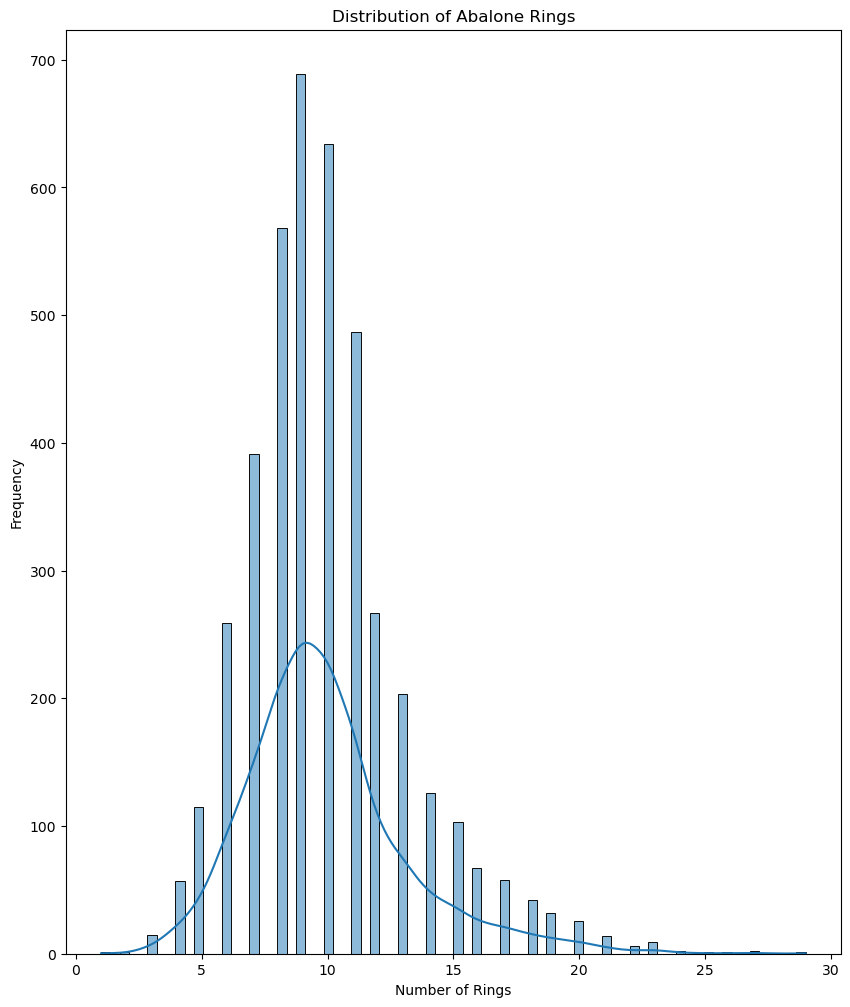

In [15]:
# distributiono of rings 
plt.figure(figsize=(10,12))
sns.histplot(df["Rings"], kde=True)
plt.xlabel("Number of Rings")
plt.ylabel("Frequency")
plt.title("Distribution of Abalone Rings")
plt.show()

In [16]:
 # Distribution of Sex (Categorical Feature)
df["Sex"].value_counts()

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

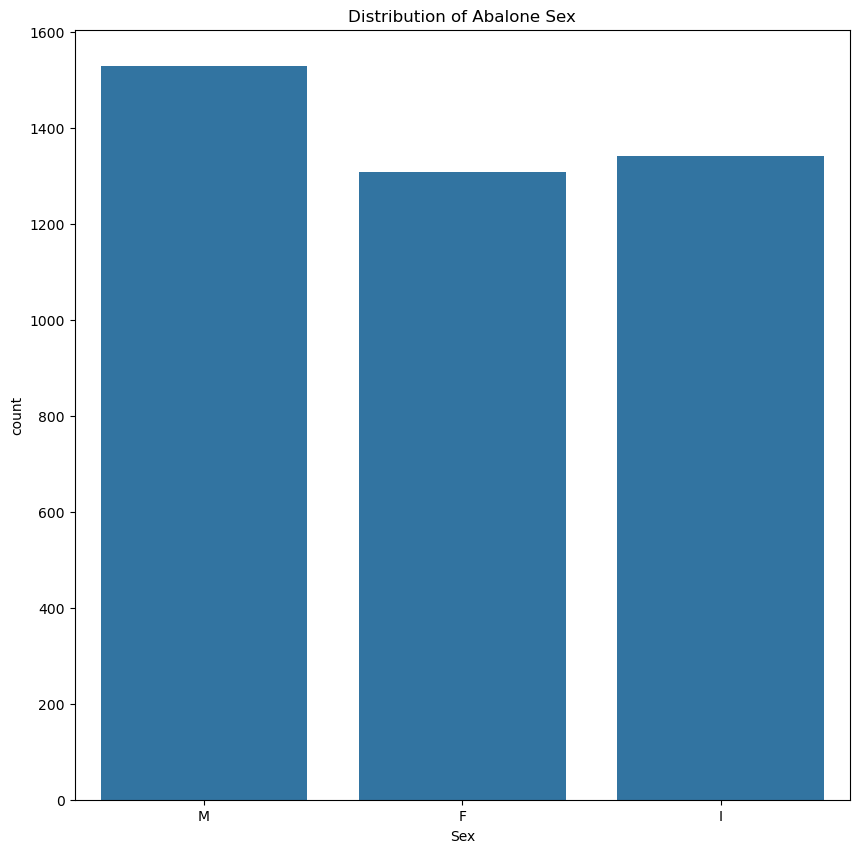

In [17]:
# Sex Distribution
plt.figure(figsize=(10,10))
sns.countplot(x = df["Sex"],data=df )
plt.title("Distribution of Abalone Sex")
plt.show()

# Data Preprocessing 

In [19]:
# Create the Target Variable (Age)
df["Age"] = df["Rings"] + 1.5  

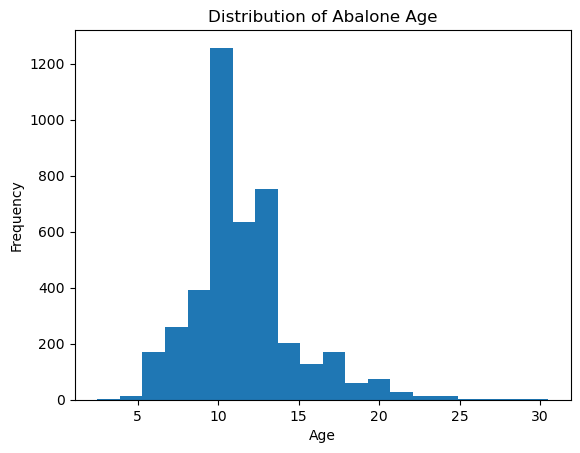

In [20]:
# Distribution of abalone age 

plt.hist(df["Age"], bins=20)
plt.title("Distribution of Abalone Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [21]:
df[["Rings", "Age"]].head()

,Rings,Age
0,15,16.5
1,7,8.5
2,9,10.5
3,10,11.5
4,7,8.5


### Handle Categorical Data

In [23]:
df_encoded = pd.get_dummies(df, columns=["Sex"], drop_first=True)

In [24]:
df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Age,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5,True,False


In [25]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          4177 non-null   float64
 1   Diameter        4177 non-null   float64
 2   Height          4177 non-null   float64
 3   Whole_weight    4177 non-null   float64
 4   Shucked_weight  4177 non-null   float64
 5   Viscera_weight  4177 non-null   float64
 6   Shell_weight    4177 non-null   float64
 7   Rings           4177 non-null   int64  
 8   Age             4177 non-null   float64
 9   Sex_I           4177 non-null   bool   
 10  Sex_M           4177 non-null   bool   
dtypes: bool(2), float64(8), int64(1)
memory usage: 302.0 KB


# FEATURE SELECTION

In [27]:
# Define y 
y = df_encoded["Age"]

# Define x (removing data leakage)
X = df_encoded.drop(["Rings","Age"], axis=1)

In [28]:
# shapes 
X.shape, y.shape

((4177, 9), (4177,))

# TRAIN–TEST SPLIT

In [30]:
# Perform the Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [31]:
# Verify the split 
X_train.shape, X_test.shape 

((3341, 9), (836, 9))

# FEATURE SCALING

In [33]:
# Applying Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scales = scaler.transform(X_test)

In [34]:
# Verify Scaling Worked
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5,6,7,8
count,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03
mean,5.635852e-16,2.041667e-16,-3.105036e-16,-1.063368e-17,2.530817e-16,1.680122e-16,1.828994e-16,4.678821e-17,2.126737e-17
std,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00
min,-3.777412e+00,-3.582758e+00,-3.288610e+00,-1.686311e+00,-1.612494e+00,-1.647965e+00,-1.702271e+00,-6.887701e-01,-7.589093e-01
25%,-6.293175e-01,-5.930591e-01,-5.832029e-01,-7.890755e-01,-7.805961e-01,-8.026546e-01,-7.838882e-01,-6.887701e-01,-7.589093e-01
50%,1.681999e-01,1.670339e-01,4.928971e-03,-5.867303e-02,-1.056604e-01,-8.985185e-02,-4.060562e-02,-6.887701e-01,-7.589093e-01
75%,7.558443e-01,7.244354e-01,5.930609e-01,6.513840e-01,6.410292e-01,6.640741e-01,6.347810e-01,1.451863e+00,1.317680e+00
max,2.434828e+00,2.447313e+00,2.329495e+01,4.058233e+00,5.056140e+00,5.292723e+00,5.469691e+00,1.451863e+00,1.317680e+00


# MODEL TRAINING

## Linear Regression Training

In [37]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
lr.coef_

array([-0.02400903,  1.09756883,  0.44400437,  4.39025206, -4.51688977,
       -1.04600537,  1.23022841, -0.33586996,  0.04973353])

## Random Forest Regression Training

In [40]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf.feature_importances_

array([0.04994207, 0.05483224, 0.05434602, 0.07934977, 0.1692341 ,
       0.0674528 , 0.4981786 , 0.01875017, 0.00791423])

## Support Vector Regression (SVR) Training

In [43]:
svr = SVR(kernel="rbf", C=100, gamma="scale")
svr.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


# MODEL EVALUATION

### Generate Predictions

In [46]:
# Linear Regression predictions
y_pred_lr = lr.predict(X_test_scales)

# Random Forest predictions
y_pred_rf = rf.predict(X_test)

# SVR predictions
y_pred_svr = svr.predict(X_test_scales)

### Compute Metrics 

In [48]:
# Linear Regression 
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)



# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


# SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

## Inspect result 

#### Linear Regression  

In [51]:
mae_lr, rmse_lr, r2_lr

(1.5931067816608362, np.float64(2.2116130871218367), 0.5481628137889263)

#### Random Forest 

In [53]:
mae_rf, rmse_rf, r2_rf

(1.5895933014354064, np.float64(2.2638382531363934), 0.5265714369702403)

#### SVR

In [55]:
mae_svr, rmse_svr, r2_svr

(1.4991141355776199, np.float64(2.200752510822084), 0.552589594704696)

# MODEL COMPARISON & FINAL CONCLUSION 

In [57]:
# Comparison Table
model_comparision_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVR"],
    "MAE": [mae_lr, mae_rf, mae_svr],
    "RMSE": [rmse_lr, rmse_rf, rmse_svr],
    "R2 Score": [r2_lr, r2_rf, r2_svr]
})

model_comparision_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.593107,2.211613,0.548163
1,Random Forest,1.589593,2.263838,0.526571
2,SVR,1.499114,2.200753,0.552590


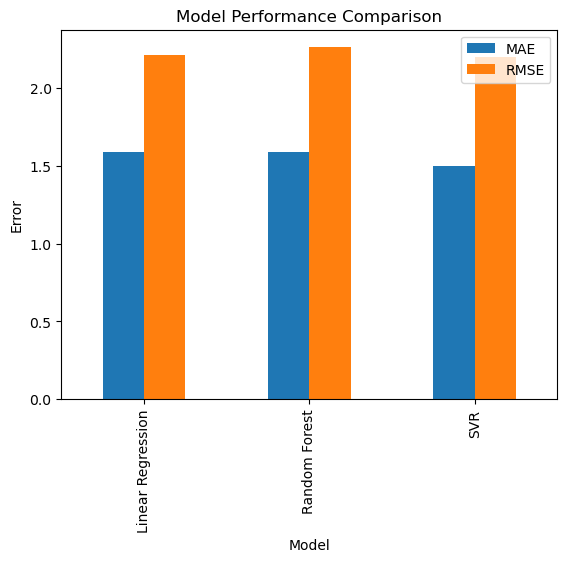

In [58]:
# Model performance comparision 

model_comparision_results.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.show()

## Final Model Selection

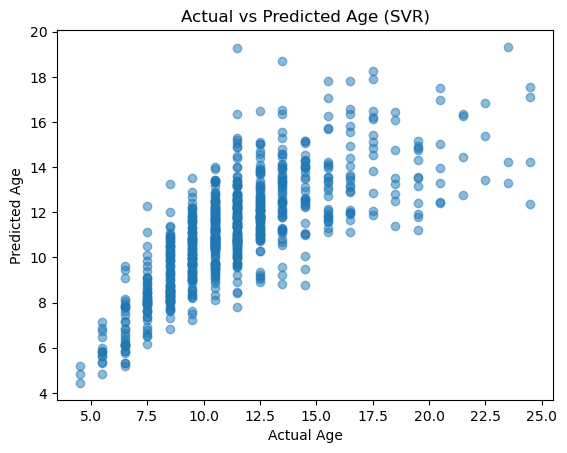

In [60]:
# Actual vs predicted age 
plt.scatter(y_test, y_pred_svr, alpha=0.5)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age (SVR)")
plt.show()

In [61]:
y_test

866     10.5
1483     9.5
599     17.5
1702    10.5
670     15.5
        ... 
3093    12.5
1651     9.5
2897    11.5
3953     9.5
1830     8.5
Name: Age, Length: 836, dtype: float64

In [62]:
y_pred_svr

array([12.70492708, 10.81870793, 16.19909708, 12.4534304 , 13.36237725,
       11.81811649, 10.4862323 ,  9.85391173,  8.17296151, 11.36020173,
       13.30560342,  8.56207521, 16.56932286,  8.62464083,  9.70262796,
       14.93375325, 13.6817355 , 12.03616558, 14.28010524,  9.57244062,
       16.35652304, 11.1012723 , 12.19987701, 11.81416462, 10.58334046,
        8.75848984, 10.81384161,  9.05402892, 10.47495881, 12.19303043,
       12.20814775, 11.8063182 ,  8.18036882, 12.23981391,  9.73379754,
       10.44816191,  7.46510526,  4.44271682,  9.39921285,  7.87990139,
       13.54817659, 18.72116481, 12.40210127, 10.14687578, 12.4613371 ,
       12.50121734, 10.47396113,  9.73789566, 14.74910132,  7.16022395,
        8.00591764, 19.32357506, 10.2921427 ,  5.30480813,  8.0481117 ,
       11.40438008, 12.00902983, 15.38322338, 10.76511894,  9.73593746,
       12.84484504, 13.99003393, 10.93662708,  8.64481293,  8.87440009,
       11.80755714,  5.98367675,  7.79692668,  9.86468457, 13.40